# SpaceX Falcon 9 Landing Prediction Models


This notebook analyzes SpaceX Falcon 9 launch data to explore factors affecting first-stage landing success and build predictive models.


## Objective
- Standardize the engineered feature set.
- Train multiple classifiers for landing-success prediction.
- Compare model performance using cross-validation and test-set accuracy.


In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = next(
    candidate
    for candidate in [Path.cwd().resolve(), *Path.cwd().resolve().parents]
    if (candidate / "data").exists() and (candidate / "notebooks").exists()
)
NOTEBOOKS_DIR = PROJECT_ROOT / "notebooks"
if str(NOTEBOOKS_DIR) not in sys.path:
    sys.path.append(str(NOTEBOOKS_DIR))

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn import preprocessing
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

from notebook_utils import data_path, ensure_binary_file

sns.set_theme(style="whitegrid")


## Data Loading


In [2]:
DATASET_PART_2_URL = (
    "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/"
    "IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv"
)
DATASET_PART_3_URL = (
    "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/"
    "IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_3.csv"
)

part_2_path = data_path("dataset_part_2.csv")
part_3_path = data_path("dataset_part_3.csv")
if not part_2_path.exists():
    part_2_path = ensure_binary_file("dataset_part_2.csv", DATASET_PART_2_URL)
if not part_3_path.exists():
    part_3_path = ensure_binary_file("dataset_part_3.csv", DATASET_PART_3_URL)

data = pd.read_csv(part_2_path)
X = pd.read_csv(part_3_path)
X.head()


,FlightNumber,PayloadMass,Flights,GridFins,Reused,Legs,Block,ReusedCount,Orbit_ES-L1,Orbit_GEO,...,Serial_B1048,Serial_B1049,Serial_B1050,Serial_B1051,Serial_B1054,Serial_B1056,Serial_B1058,Serial_B1059,Serial_B1060,Serial_B1062
0,1.0,6104.959412,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2.0,525.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3.0,677.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4.0,500.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5.0,3170.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [3]:
def plot_confusion_matrix(y_true, y_pred, title):
    matrix = confusion_matrix(y_true, y_pred)
    ax = plt.subplot()
    sns.heatmap(matrix, annot=True, fmt="d", cmap="Blues", ax=ax)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_title(title)
    ax.xaxis.set_ticklabels(["No landing", "Landing"])
    ax.yaxis.set_ticklabels(["No landing", "Landing"])
    plt.show()


## Feature Engineering


In [4]:
y = data["Class"].to_numpy()
scaler = preprocessing.StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=2,
)
X_train.shape, X_test.shape


((72, 80), (18, 80))

## Model Training


Best logistic regression parameters: {'C': 1, 'penalty': 'l2', 'solver': 'lbfgs'}
Cross-validation accuracy: 0.8214285714285714
Test accuracy: 0.8333333333333334


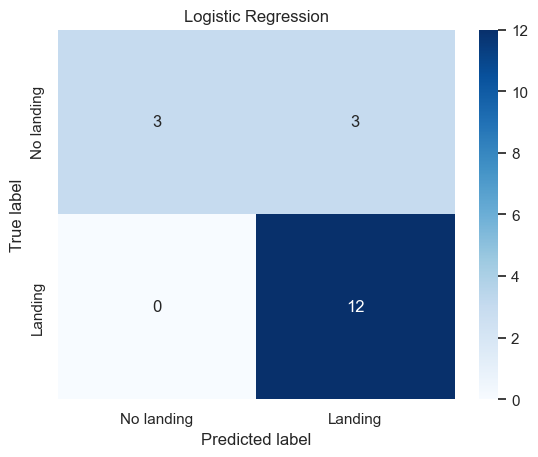

In [5]:
logreg_parameters = {"C": [0.01, 0.1, 1], "penalty": ["l2"], "solver": ["lbfgs"]}
logreg_search = GridSearchCV(
    LogisticRegression(max_iter=1000),
    logreg_parameters,
    scoring="accuracy",
    cv=10,
)
logreg_cv = logreg_search.fit(X_train, y_train)
print("Best logistic regression parameters:", logreg_cv.best_params_)
print("Cross-validation accuracy:", logreg_cv.best_score_)
print("Test accuracy:", logreg_cv.score(X_test, y_test))
plot_confusion_matrix(y_test, logreg_cv.predict(X_test), "Logistic Regression")


Best SVM parameters: {'C': 0.1, 'gamma': 0.1, 'kernel': 'sigmoid'}
Cross-validation accuracy: 0.8339285714285714
Test accuracy: 0.8333333333333334


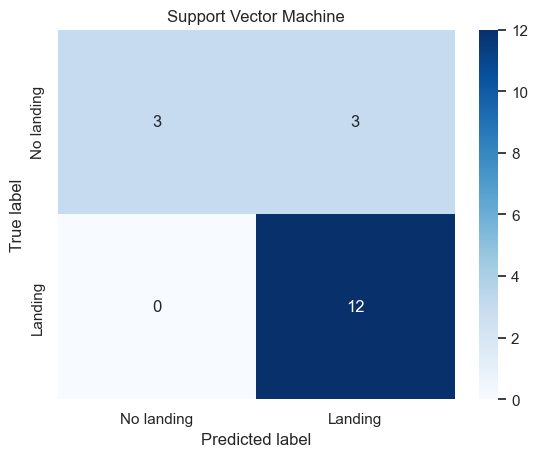

In [6]:
svm_parameters = {
    "kernel": ["linear", "rbf", "poly", "sigmoid"],
    "C": [0.001, 0.1, 1, 10, 1000],
    "gamma": [0.001, 0.1, 1, 10, 1000],
}
svm_search = GridSearchCV(SVC(), svm_parameters, scoring="accuracy", cv=10)
svm_cv = svm_search.fit(X_train, y_train)
print("Best SVM parameters:", svm_cv.best_params_)
print("Cross-validation accuracy:", svm_cv.best_score_)
print("Test accuracy:", svm_cv.score(X_test, y_test))
plot_confusion_matrix(y_test, svm_cv.predict(X_test), "Support Vector Machine")


Best decision tree parameters: {'criterion': 'entropy', 'max_depth': 14, 'max_features': None, 'min_samples_leaf': 4, 'min_samples_split': 5, 'splitter': 'best'}
Cross-validation accuracy: 0.8714285714285713
Test accuracy: 0.7777777777777778


/opt/anaconda3/lib/python3.13/site-packages/numpy/ma/core.py:2896: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


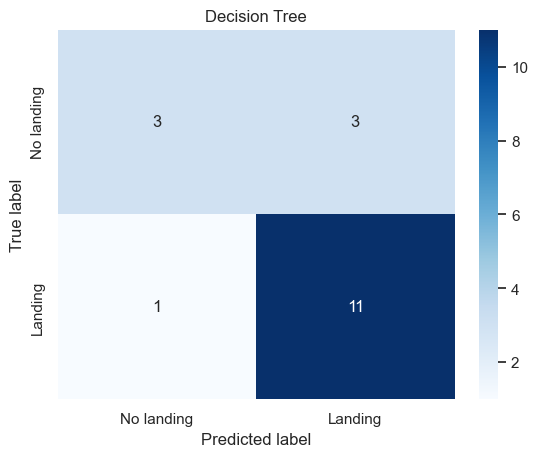

In [7]:
tree_parameters = {
    "criterion": ["gini", "entropy"],
    "splitter": ["best", "random"],
    "max_depth": [2 * n for n in range(1, 10)],
    "max_features": ["sqrt", "log2", None],
    "min_samples_leaf": [1, 2, 4],
    "min_samples_split": [2, 5, 10],
}
tree_search = GridSearchCV(DecisionTreeClassifier(), tree_parameters, scoring="accuracy", cv=10)
tree_cv = tree_search.fit(X_train, y_train)
print("Best decision tree parameters:", tree_cv.best_params_)
print("Cross-validation accuracy:", tree_cv.best_score_)
print("Test accuracy:", tree_cv.score(X_test, y_test))
plot_confusion_matrix(y_test, tree_cv.predict(X_test), "Decision Tree")


Best KNN parameters: {'algorithm': 'auto', 'n_neighbors': 6, 'p': 1}
Cross-validation accuracy: 0.8339285714285714
Test accuracy: 0.8333333333333334


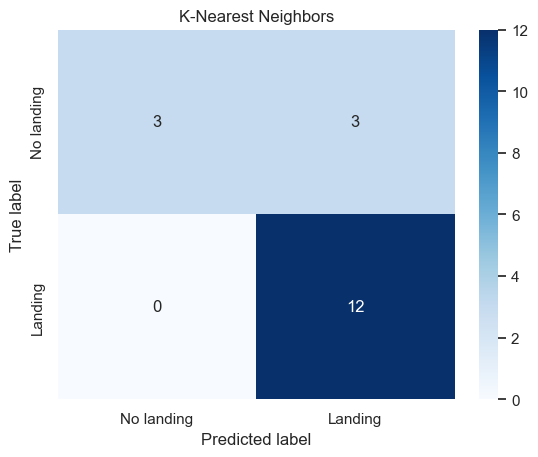

In [8]:
knn_parameters = {
    "n_neighbors": list(range(1, 11)),
    "algorithm": ["auto", "ball_tree", "kd_tree", "brute"],
    "p": [1, 2],
}
knn_search = GridSearchCV(KNeighborsClassifier(), knn_parameters, scoring="accuracy", cv=10)
knn_cv = knn_search.fit(X_train, y_train)
print("Best KNN parameters:", knn_cv.best_params_)
print("Cross-validation accuracy:", knn_cv.best_score_)
print("Test accuracy:", knn_cv.score(X_test, y_test))
plot_confusion_matrix(y_test, knn_cv.predict(X_test), "K-Nearest Neighbors")


## Evaluation


In [9]:
model_scores = pd.Series(
    {
        "Logistic Regression": logreg_cv.best_score_,
        "Support Vector Machine": svm_cv.best_score_,
        "Decision Tree": tree_cv.best_score_,
        "K-Nearest Neighbors": knn_cv.best_score_,
    }
).sort_values(ascending=False)
model_scores


Decision Tree             0.871429
Support Vector Machine    0.833929
K-Nearest Neighbors       0.833929
Logistic Regression       0.821429
dtype: float64

## Key Findings
The score comparison above highlights which model generalized best during cross-validation on the engineered Falcon 9 feature set.
